In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline


import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("Train_data.csv")

# Drop ID
df = df.drop(columns=['Customer Id'])

# Clean NumberOfWindows
df['NumberOfWindows'] = df['NumberOfWindows'].astype(str).str.strip()
df['NumberOfWindows'] = df['NumberOfWindows'].replace('.', np.nan)
df['NumberOfWindows'] = pd.to_numeric(df['NumberOfWindows'], errors='coerce')

X = df.drop(columns=['Claim'])
y = df['Claim']


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numerical_features = [
    'Insured_Period',
    'Building Dimension',
    'Date_of_Occupancy',
    'YearOfObservation',
    'NumberOfWindows'
]

categorical_features = [
    'Residential',
    'Building_Painted',
    'Building_Fenced',
    'Garden',
    'Settlement',
    'Building_Type',
    'Geo_Code'
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [7]:
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Insured_Period',
                                                   'Building Dimension',
                                                   'Date_of_Occupancy',
                                                   'YearOfObservation',
                                                   'NumberOfWindows']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Residential',
                                                   'Building_Painted',
                                                   'Building_Fenced', 'Garden',
                                                   'Settlement',
                                                   'Building_Type',
                                                   'Geo_Code'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [8]:
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))


              precision    recall  f1-score   support

           0       0.83      0.73      0.78      1105
           1       0.36      0.51      0.42       327

    accuracy                           0.68      1432
   macro avg       0.60      0.62      0.60      1432
weighted avg       0.73      0.68      0.70      1432

ROC-AUC: 0.6833298739396958


Logistic Regression serves as a baseline

Class weights help handle imbalance

Provides interpretable probabilities

In [9]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42,
        class_weight='balanced'
    ))
])

rf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Insured_Period',
                                                   'Building Dimension',
                                                   'Date_of_Occupancy',
                                                   'YearOfObservation',
                                                   'NumberOfWindows']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Residential',
                                                   'Building_Painted',
                                                   'Building_Fenced', 'Garden',
                                                   'Settlement',
                                                   'Building_Type',
                                                   'Geo_Code'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])

In [10]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1105
           1       0.45      0.31      0.37       327

    accuracy                           0.75      1432
   macro avg       0.63      0.60      0.61      1432
weighted avg       0.73      0.75      0.74      1432

ROC-AUC: 0.675060539388656


Captures non-linear relationships

Handles feature interactions automatically

More expressive than logistic regression

In [11]:
!pip install xgboost


In [12]:
from xgboost import XGBClassifier

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Insured_Period',
                                                   'Building Dimension',
                                                   'Date_of_Occupancy',
                                                   'YearOfObservation',
                                                   'NumberOfWindows']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneH...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [13]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


              precision    recall  f1-score   support

           0       0.81      0.95      0.87      1105
           1       0.58      0.23      0.33       327

    accuracy                           0.79      1432
   macro avg       0.69      0.59      0.60      1432
weighted avg       0.75      0.79      0.75      1432

ROC-AUC: 0.6999100557654254


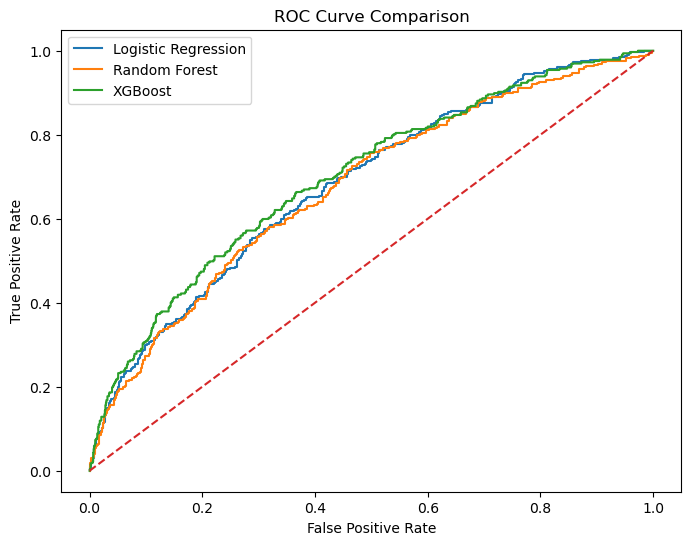

In [14]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
